# 1.환경 준비
- 데이터 : airquality_simple.csv
- KNN(K-Nearest Neighbor) 모델을 만들고 평가한다.
- 회귀와 분류에 사용되는 매우 간단한 지도학습 알고리즘이다.
- 다른 알고리즘에 비해 이해하기 쉽지만, 연산 속도가 느리다.

In [1]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

In [2]:
path = './../00_data/airquality.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [3]:
df.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5


In [4]:
df.describe()

,Ozone,Solar.R,Wind,Temp,Month,Day
count,116.000000,146.000000,153.000000,153.000000,153.000000,153.000000
mean,42.129310,185.931507,9.957516,77.882353,6.993464,15.803922
std,32.987885,90.058422,3.523001,9.465270,1.416522,8.864520
min,1.000000,7.000000,1.700000,56.000000,5.000000,1.000000
25%,18.000000,115.750000,7.400000,72.000000,6.000000,8.000000
50%,31.500000,205.000000,9.700000,79.000000,7.000000,16.000000
75%,63.250000,258.750000,11.500000,85.000000,8.000000,23.000000
max,168.000000,334.000000,20.700000,97.000000,9.000000,31.000000


In [5]:
df.isna().sum()

Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

# 3.데이터 전처리

**1) 결측치 처리**

- 결측치가 있으면 제거하거나 적절한 값으로 채운다.
- 시계열 데이터이므로 선형보간법으로 채운다.

In [7]:
df.interpolate(method='linear', inplace=True)

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.000000,7.4,67,5,1
1,36.0,118.000000,8.0,72,5,2
2,12.0,149.000000,12.6,74,5,3
3,18.0,313.000000,11.5,62,5,4
4,23.0,308.333333,14.3,56,5,5
...,...,...,...,...,...,...
148,30.0,193.000000,6.9,70,9,26
149,22.0,145.000000,13.2,77,9,27
150,14.0,191.000000,14.3,75,9,28
151,18.0,131.000000,8.0,76,9,29


In [8]:
df.isna().sum()

Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64

**2) 변수 제거**

- 분석에 의미가 없다고 판단되는 변수는 제거한다.
- Month, Day 열을 제거한다.

In [9]:
drop_cols = ['Month', 'Day']
df.drop(drop_cols, axis=1, inplace=True)

df.head()

,Ozone,Solar.R,Wind,Temp
0,41.0,190.000000,7.4,67
1,36.0,118.000000,8.0,72
2,12.0,149.000000,12.6,74
3,18.0,313.000000,11.5,62
4,23.0,308.333333,14.3,56


**3) x, y 분리**

In [10]:
target = 'Ozone'

X = df.drop(target, axis=1)
y = df[target]

**4) 학습용, 평가용 데이터 분리**

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=1)

**4) 정규화**

- KNN 알고리즘을 사용하기 위해 정규화 진행

✅ (올바른 방법) 학습 데이터의 최소/최댓값으로 평가 데이터 정규화
- 이렇게 하면 학습과 평가 과정에서 데이터 분포가 일관되게 유지됨
- 이 방법을 사용해야 모델이 올바르게 평가될 수 있음

❌ (잘못된 방법) 평가 데이터의 최소/최댓값으로 정규화
- 이렇게 되면 평가 데이터가 모델이 학습한 데이터 분포와 달라져 모델 성능이 왜곡됨
- 평가 과정에서 예상치 못한 결과가 나올 가능성이 커짐

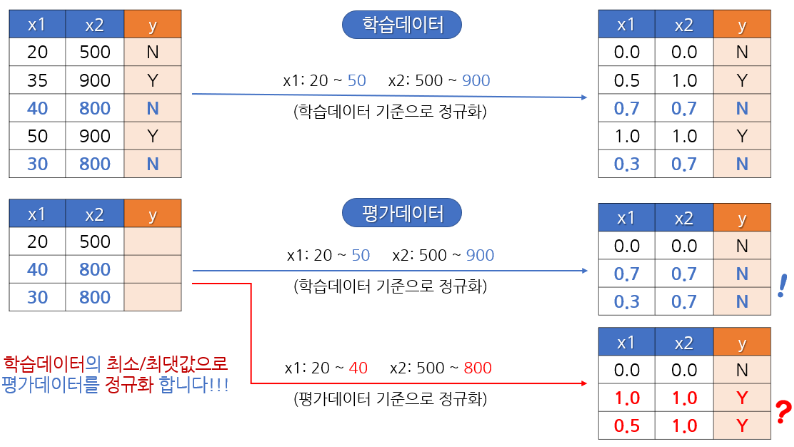

- 다음 중 한 가지 방법을 사용해 진행한다.

- 방법1: 공식 사용

$$ \large x_{norm}=\frac{x-x_{min}}{x_{max}-x_{min}}$$

In [12]:
# 최댓값, 최솟값 구하기
X_max = X_train.max()
X_min = X_train.min()

In [ ]:
# 정규화
X_train = (X_train - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)

# print(X_)

- 방법2: 함수 사용

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
# 정규화
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# 4.모델링

In [16]:
# 1단계: 불러오기
# from sklearn.neighbors import KNeighborsClassifier # 분류
from sklearn.neighbors import KNeighborsRegressor # 회귀

from sklearn.metrics import mean_absolute_error, r2_score

In [17]:
# 2단계: 선언하기
model = KNeighborsRegressor()

In [18]:
# 3단계: 학습하기
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [20]:
# 4단계 예측하기
y_pred = model.predict(X_test)

In [21]:
# 5단계: 평가하기
print('MAE : ', mean_absolute_error(y_test, y_pred))
print('r2 score', r2_score(y_test, y_pred))

MAE :  18.683375682288727
r2 score 0.2877906019226045


# 5.기타

- 기타 필요한 내용이 있으면 진행한다.

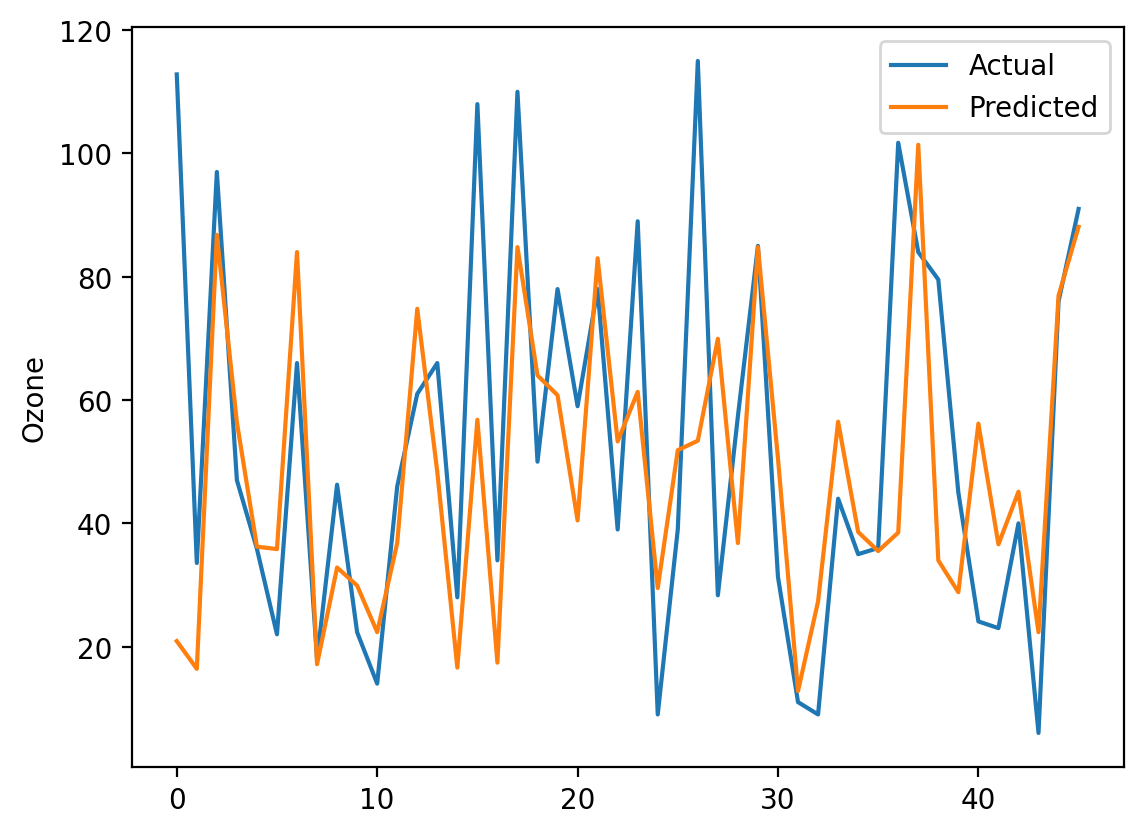

In [22]:
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.ylabel('Ozone')
plt.show()